# LLM4Series Tutorial

Welcome to the `llm4series` tutorial! This notebook will guide you through the process of using Large Language Models for time series forecasting.
First, let's install the library.

In [ ]:
!git clone https://github.com/llm4time/llm4series.git

Cloning into 'llm4series'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 101 (delta 26), reused 87 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 3.94 MiB | 12.01 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [ ]:
!pip install git+https://github.com/llm4time/llm4series.git

In [ ]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")
os.environ["DEEPSEEK_API_KEY"] = getpass("DeepSeek API key: ")

OpenAI API key: ··········
DeepSeek API key: ··········


# Data Preprocessing

In this section, we load our time series data and handle basic preprocessing. We use `l4s.read_file` to load the dataset and set the timestamp column as the index.

In [ ]:
import llm4series as l4s

# Read the CSV file and set 'data_hora' as the index (timestamps)
ts = l4s.read_file('llm4series/examples/data/busline.csv', index_col='date')
ts.head()

,validations_per_hour
date,
2018-01-01 00:00:00,0.0
2018-01-01 01:00:00,0.0
2018-01-01 02:00:00,0.0
2018-01-01 03:00:00,0.0
2018-01-01 04:00:00,15.0


In [ ]:
type(ts)

llm4series.data.ts.UniTimeSeries

## Missing Values and Duplicates

Real-world time series data often contains missing values or duplicate timestamps. Here, we check for these issues and handle them by interpolating missing values and aggregating duplicates.

In [ ]:
# Check the number of missing values in the time series
missing_values = ts.isna().sum()

# Check the number of duplicated timestamps in the index
duplicate_dates = ts.index.duplicated().sum()

# Print initial diagnostics
print("Before cleaning:")
print("Missing values:", missing_values)
print("Duplicate timestamps:", duplicate_dates)

# Handle missing values (if any) using interpolation
# impute_mean(), impute_median(), and others...
if missing_values > 0:
    ts = ts.impute_interpolate('linear')

# Handle duplicate timestamps (if any) by aggregating values using sum
if duplicate_dates > 0:
    ts = ts.agg_duplicates(method="sum")

# Recalculate after cleaning
missing_values = ts.isna().sum()
duplicate_dates = ts.index.duplicated().sum()

# Print final diagnostics
print("\nAfter cleaning:")
print("Missing values:", missing_values)
print("Duplicate timestamps:", duplicate_dates)

Before cleaning:
Missing values: 0
Duplicate timestamps: 28

After cleaning:
Missing values: 0
Duplicate timestamps: 0


In [ ]:
train, test = ts.split(start="2018-04-06 14:00:00", end="2018-06-16 13:00:00",periods=24)
print(len(train), len(test))

1704 24


# Dataset Characteristics

Before modeling, it's crucial to understand the characteristics of our time series data. We can visualize it using different plots.

### Time Series Line Chart
Plotting the original time series helps us identify general trends and patterns.

In [ ]:
ts.plot('chart', title="Bus line")

### STL Decomposition
STL decomposition separates the time series into trend, seasonal, and residual components, providing deeper insights.

Time series decomposition is crucial for several reasons:
- It helps understand underlying patterns like trends, seasonality, and residuals.
- It aids in improving forecasting models by isolating and modeling these components.
- It facilitates anomaly detection and allows for better feature engineering.

To futher comprehension: https://www.geeksforgeeks.org/data-analysis/seasonal-decomposition-of-time-series-by-loess-stl/

In [ ]:
ts.plot('stl', title="STL Decomposition")

### Descriptive Statistics
We can also view statistical descriptions of our data as a bar chart.

In [ ]:
ts.plot('bar', title="Statistical Descriptions")

# Prompt Construction

To use LLMs for forecasting, we need to construct appropriate prompts. `llm4series` allows us to create custom prompts or use zero-shot templates.

Use the l4s.prompt function to construct a prompt that will be sent to a Large Language Model for time series forecasting

In [ ]:
l4s_prompt = l4s.prompt(
    ts=train,
    forecast_horizon=24,
    tsformat="plain",
    tstype="textual",
    sampling="uniform",
    type="cot" #few-shot, zero-shot and cot_few (inference strategies)
)

Examples of formatting:

**Plain Format** \
The ``Plain'' format explicitly labels each timestamp and observation. While this increases the token overhead per data point, it provides clear semantic anchors, which can be particularly beneficial for zero-shot reasoning.

Date: 2020-01-01, Value: 100 \
Date: 2020-01-02, Value: 105 \
Date: 2020-01-03, Value: 103 \
Date: 2020-01-04, Value: 103

**CSV Format** \
The CSV format is highly token-efficient, relying on the model's ability to infer the schema from a single header line. This representation is ideal for longer sequences, as it reduces the structural noise within the context window.

Date,Value \
2020-01-01,100 \
2020-01-02,105 \
2020-01-03,103 \
2020-01-04,103

In [ ]:
l4s_prompt

'Objective:\nPredict the next 24 values based on the historical series (1704 periods).\n\nStatistical Context (to guide the forecast):\n- Mean: 512.689\n- Median: 530.5\n- Standard Deviation: 376.3694\n- Minimum Value: 0.0\n- Maximum Value: 1559.0\n- First Quartile (Q1): 160.0\n- Third Quartile (Q3): 729.0\n\nReasoning Instructions:\nBefore generating the forecast, analyze the historical series step by step, considering:\n- Trend: Identify the overall direction (increasing, decreasing, stable) and the trend strength.\n- Seasonality: Patterns that repeat at regular intervals (e.g., daily, weekly, monthly).\n- Outliers: Possible outliers or abrupt changes.\n- Cycles: Not seasonal long-term patterns.\n- Noise reduction: Apply a technique to reduce noise when necessary.\n- Consistency with the provided descriptive statistics (mean, median, etc.).\n- Adjustment for data frequency and contextual events (holidays, promotions, etc.).\n\nSteps:\n1. Analyze the series step by step (internally; d

In [ ]:
template = """
  You are an expert in time series forecasting.

  Given the following time series data, predict the next {forecast_horizon} values.

  Output format:
  {output_example}

  Provide the final forecast inside <out></out>.
"""

In [ ]:
custom_prompt = l4s.prompt(
    ts=train,
    forecast_horizon=24,
    type="custom",
    template=template,
    tsformat="plain",
    tstype="textual"
)

# Experiments

Now we run our forecasting experiments. We initialize the LLM, format our data, and request predictions.

In [ ]:
model = l4s.OpenAI(model="gpt-5", api_key=os.getenv("OPENAI_API_KEY"), base_url="https://api.openai.com/v1")

data = train.to_str(format="plain", type="textual")

response = model.predict(l4s_prompt, data, temperature = 1)

predicted = l4s.from_str(response.predicted, format="plain")

l4s.lineplot(test, predicted, groups=["Original series", "Forecast"])

In [ ]:
metrics = test.metrics(predicted)["validations_per_hour"]
print(metrics["smape"], metrics["mae"], metrics["rmse"])

11.56 31.71 49.59


## Test and Compare different Prompts

In [ ]:
response_custom = model.predict(custom_prompt, data, temperature= 1)

predicted_custom = l4s.from_str(response_custom.predicted, format="plain")

l4s.lineplot(test, predicted_custom, groups=["Original series", "Forecast"])

In [ ]:
metrics_custom = test.metrics(predicted_custom)["validations_per_hour"]

print("Custom prompt:")
print(metrics_custom["smape"], metrics_custom["mae"], metrics_custom["rmse"])
print("LLM4Series prompt:")
print(metrics["smape"], metrics["mae"], metrics["rmse"])

Custom prompt:
49.29 242.42 308.68
LLM4Series prompt:
11.56 31.71 49.59


## Test and Compare different Types

Careful **tokenization is important for good forecasting with LLMs**. We show how **GPT-5** and **Qwen3** tokenize the same sequence and how this affects forecasting performance. Adding spaces allows the models to create one token per digit, which can improve the representation of the sequence. Without spaces, numbers tend to be tokenized as larger chunks, which may change the model behavior and affect forecasting performance.


Examples of Type:

**Numeric** \

Date,Value \
2020-01-01, 100 \
2020-01-02, 105 \
2020-01-03, 103 \
2020-01-04, 103

**Textual** \

Date,Value \
2020-01-01, 1 0 0 \
2020-01-02, 1 0 5 \
2020-01-03, 1 0 3 \
2020-01-04, 1 0 3

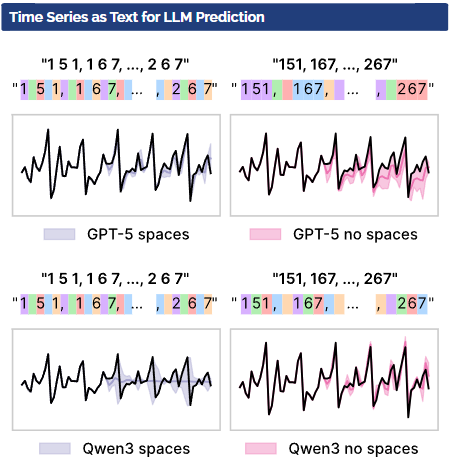

In [ ]:
l4s_prompt_numeric = l4s.prompt(
    ts=train,
    forecast_horizon=24,
    tsformat="plain",
    tstype="numeric",
    sampling="uniform",
    type="cot")

In [ ]:
# 1. Format the data as numeric and predict
data_numeric = train.to_str(format="plain", type="numeric")

response_numeric = model.predict(l4s_prompt_numeric, data_numeric, temperature=1)

predicted_numeric = l4s.from_str(response_numeric.predicted, format="plain")

# 3. Plot the comparison between Textual and Numeric
l4s.lineplot(test, predicted, predicted_numeric,
             groups=["Original series", "Textual Forecast", "Numeric Forecast"])

# 4. Calculate and print metrics
metrics_textual = test.metrics(predicted)["validations_per_hour"]
metrics_numeric = test.metrics(predicted_numeric)["validations_per_hour"]

print("--- Comparison Results ---")
print(f"Textual Format - SMAPE: {metrics_textual['smape']:.2f}, MAE: {metrics_textual['mae']:.2f}, RMSE: {metrics_textual['rmse']:.2f}")
print(f"Numeric Format - SMAPE: {metrics_numeric['smape']:.2f}, MAE: {metrics_numeric['mae']:.2f}, RMSE: {metrics_numeric['rmse']:.2f}")

--- Comparison Results ---
Textual Format - SMAPE: 10.31, MAE: 26.92, RMSE: 38.45
Numeric Format - SMAPE: 10.72, MAE: 25.92, RMSE: 33.98


In [ ]:
# Metadata
print("Total processing time:")
print(response_numeric.time)

print("Input tokens:")
print(response_numeric.input_tokens)

print("Output tokens:")
print(response_numeric.output_tokens)

Total processing time:
70.77299809455872
Input tokens:
43822
Output tokens:
7591


## Test and Compare Different Models

In this section, we will evaluate the performance of different models on the same dataset to see which one performs best.

In [ ]:
# Initialize three different models for comparison
# 1. DeepSeek API
model_deepseek = l4s.OpenAI(model="deepseek-reasoner", api_key=os.getenv("DEEPSEEK_API_KEY"), base_url="https://api.deepseek.com")

# 2. OpenAI API - GPT-5
model_gpt5 = l4s.OpenAI(model="gpt-5", api_key=os.getenv("OPENAI_API_KEY"), base_url="https://api.openai.com/v1")

print("Predicting with DeepSeek Reasoner...")
response_deepseek = model_deepseek.predict(l4s_prompt, data, temperature=0.7)
predicted_deepseek = l4s.from_str(response_deepseek.predicted, format="plain")

print("Predicting with GPT-5...")
response_gpt5 = model_gpt5.predict(l4s_prompt, data, temperature=1)
predicted_gpt5 = l4s.from_str(response_gpt5.predicted, format="plain")

# Extract and print metrics
metrics_deepseek = test.metrics(predicted_deepseek)["validations_per_hour"]
metrics_gpt5 = test.metrics(predicted_gpt5)["validations_per_hour"]

print(f"DeepSeek - SMAPE: {metrics_deepseek['smape']:.2f}, MAE: {metrics_deepseek['mae']:.2f}, RMSE: {metrics_deepseek['rmse']:.2f}")
print(f"GPT-5       - SMAPE: {metrics_gpt5['smape']:.2f}, MAE: {metrics_gpt5['mae']:.2f}, RMSE: {metrics_gpt5['rmse']:.2f}")

# Plot the comparison
l4s.lineplot(test, predicted_deepseek, predicted_gpt5,
             groups=["Original series", "DeepSeek Forecast", "GPT-5 Forecast"])

Predicting with DeepSeek Reasoner...
Predicting with GPT-5...
DeepSeek - SMAPE: 11.56, MAE: 31.71, RMSE: 49.59
GPT-5       - SMAPE: 11.56, MAE: 31.71, RMSE: 49.59


# Multivariate forecasting

In [ ]:
mts = l4s.read_file("llm4series/examples/data/ETTh2.csv", index_col="date")

mtrain, mtest = mts.split(start="2016-08-12", end="2016-09-20", periods=24)

l4s_prompt = l4s.prompt(
    ts=mtrain,
    forecast_horizon=24,
    tsformat="plain",
    tstype="textual",
    sampling="uniform",
    type="zero_shot"
)

print("Generating multivariate predictions...")

data = mtrain.to_str(format="plain", type="textual")

# Using the previously defined model to predict
response = model.predict(l4s_prompt, data, temperature=1)
mpredicted = l4s.from_str(response.predicted, format="plain")

# Define the target variable for metrics
target = "OT"

Generating multivariate predictions...


In [ ]:
# Calculate and print metrics
metrics = l4s.metrics(
    y_true=mtest[target],
    y_pred=mpredicted[target]
)

print(f"\nMetrics for the column '{target}':")
print(metrics)


Metrics for the column 'OT':
         OT
smape  6.78
mae    2.22
rmse   2.45


In [ ]:
# Plotting to compare the real values (mtest) with the predicted values (mpredicted)
print(f"\nPlotting real vs predicted values (Target: {target}):")
l4s.lineplot(mtest, mpredicted, groups=["Original series", "Forecast"])


Plotting real vs predicted values (Target: OT):
